In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
def isDiagonallyDominant(x):
    x = np.array(x)
    diag = np.diag(np.abs(x))
    offDiag = np.sum(np.abs(x), axis=1) - diag

    if np.all(diag > offDiag):
        return True
    else:
        return False
    
def gaussSeidel(x, y, epsilon = 0.01, t = 15):
    if not isDiagonallyDominant(x):
        print("Matrix is NOT diagonally dominant")
        return
    
    x = np.array(x)
    y = np.array(y)

    diag = np.diag(np.abs(x))
    x = -x
    np.fill_diagonal(x, 0)
    mtxOld = np.zeros(x[0].shape)

    for i in range(t):
        mtxNew = np.array(mtxOld)

        for idx, row in enumerate(x):
            mtxNew[idx] = (y[idx] + np.dot(row, mtxNew)) / diag[idx]

        print(f"Iteration {i}: {mtxNew}")

        dx = np.sqrt(np.dot(mtxNew - mtxOld, mtxNew - mtxOld))

        if dx < epsilon:
            print("Converges\n")
            return
        
        mtxOld = mtxNew
        
    print("Not Converges\n")
    return

In [24]:
x = [
    [
        [10, 2, 1],
        [1, -8, 2],
        [2, 3, -9]
    ],
    [
        [-12, 2, -3],
        [3, 9, 1],
        [-2, 1, 10]
    ],
    [
        [11, -1, 3],
        [2, 7, -2],
        [3, 2, 9]
    ],
    [
        [-10, 5, 1],
        [-4, 11, -3],
        [-2, 3, -8]
    ],
    [
        [8, 1, -2],
        [-3, 10, 2],
        [-1, -2, 9]
    ]
]

y = [
    [40, 1150, 18],
    [25, -10, 15],
    [30, -10, 12],
    [80, -700, 140],
    [15, 10, -5]
]

for i, (matrixX, matrixY) in enumerate(zip(x, y)):
    print(f"Equation #{i + 1}:")
    gaussSeidel(matrixX, matrixY)

Equation #1:
Iteration 0: [  4.         143.25       -46.63888889]
Iteration 1: [-19.98611111 157.90798611 -46.19463735]
Iteration 2: [-22.96213349 158.16892602 -45.62027901]
Iteration 3: [-23.0717573  158.03903942 -45.55262263]
Iteration 4: [-23.05254562 158.01972386 -45.55045337]
Iteration 5: [-23.04889943 158.01872577 -45.55093094]
Converges

Equation #2:
Iteration 0: [ 2.08333333 -1.80555556  2.09722222]
Iteration 1: [ 2.90856481 -2.31365741  2.3130787 ]
Iteration 2: [ 3.04721258 -2.38385738  2.34782825]
Iteration 3: [ 3.06759996 -2.39451424  2.35297142]
Iteration 4: [ 3.07066189 -2.39610634  2.35374301]
Converges

Equation #3:
Iteration 0: [ 2.72727273 -2.20779221  0.91486291]
Iteration 1: [ 2.27705628 -1.81776953  0.97826336]
Iteration 2: [ 2.29522185 -1.80484528  0.96933611]
Iteration 3: [ 2.29883149 -1.80842725  0.96892889]
Converges

Equation #4:
Iteration 0: [  8.         -60.72727273  42.27272727]
Iteration 1: [ 34.13636364 -39.69421488  40.91942149]
Iteration 2: [ 23.755165

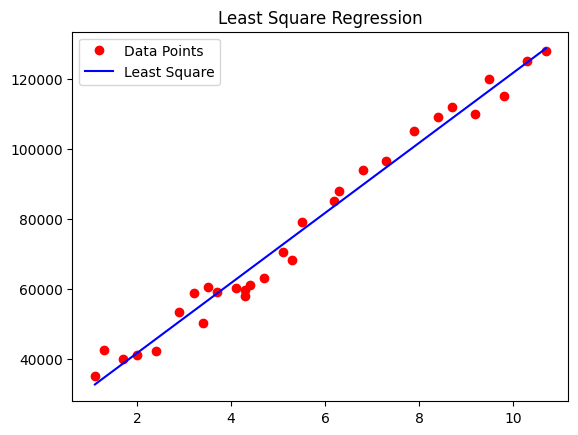

In [27]:
# Soal 2 (Least Square Regression)

x = [1.1, 1.3, 1.7, 2.0, 2.4, 2.9, 3.2, 3.4, 3.5, 3.7, 4.1, 4.3, 4.3, 4.4, 4.7, 5.1,
        5.3, 5.5, 6.2, 6.3, 6.8, 7.3, 7.9, 8.4, 8.7, 9.2, 9.5, 9.8, 10.3, 10.7]

y = [35010.0, 42500.0, 39800.0, 41050.0, 42100.0, 53200.0, 58700.0, 50200.0, 60500.0, 59000.0,
        60100.0, 58000.0, 59500.0, 61000.0, 63000.0, 70500.0, 68200.0, 79000.0, 85000.0, 88000.0,
        94000.0, 96500.0, 105000.0, 109000.0, 112000.0, 110000.0, 120000.0, 115000.0, 125000.0, 128000.0]

x = np.array(x)
y = np.array(y)

A = np.vstack([x, np.ones(len(x))]).T
y = y[:, np.newaxis]

alpha = np.dot(np.dot(np.linalg.inv(np.dot(A.T, A)), A.T), y)

plt.title("Least Square Regression")
plt.plot(x, y, "or", label="Data Points")
plt.plot(x, alpha[0] * x + alpha[1], "b", label="Least Square")
plt.legend()
plt.show()

In [35]:
# Soal 3 (Newton Raphson)

def f(x):
    return (15 * x ** 5) + (6 * x ** 4) - 9

def g(x):
    return (75 * x ** 4) + (24 * x ** 3)

def newtonRaphson(x0, tolerance, i = 0):
    x1 = x0 - f(x0) / g(x0)
    iNew = i + 1
    print(f"Iteration {iNew}: new root = {x1} with function of {f(x1)}")

    if iNew > 25:
        print("Max iteration reached")
        return
    
    if np.abs(f(x1)) < tolerance:
        print(f"The root of the equation: {x1}")
        return
    
    newtonRaphson(x1, tolerance, i + 1)

newtonRaphson(3, 0.035, 0)

Iteration 1: new root = 2.3868808567603748 with function of 1347.852461597219
Iteration 2: new root = 1.898656178466907 with function of 439.07486544949563
Iteration 3: new root = 1.5131349231884295 with function of 141.43451086983134
Iteration 4: new root = 1.2161962706387888 with function of 44.03957418227888
Iteration 5: new root = 1.0037132952031504 with function of 12.370189821891714
Iteration 6: new root = 0.8804901927302695 with function of 2.5442469253948037
Iteration 7: new root = 0.839093484390474 with function of 0.2137564342527316
Iteration 8: new root = 0.8349314235732447 with function of 0.001965139409975336
The root of the equation: 0.8349314235732447


In [ ]:
# Soal 4 (Integral Riemann)

def f(x):
    return (x ** 4) - (13 * x ** 3) + 36

a = -2
b = 2
n = 50

rectangleWidth = (b - a) / n
x = np.linspace(a, b, n)
y = f(x)

# Left Riemann
leftRiemann = rectangleWidth * np.sum(y[:n-1])
print(f"Left Riemann: {leftRiemann}")

# Right Riemann
rightRiemann = rectangleWidth * np.sum(y[1:])
print(f"Right Riemann: {rightRiemann}")

# Mid Riemann
xMid = (x[:n-1] + x[1:])/2
yMid = f(xMid)
midRiemann = rectangleWidth * np.sum(yMid)
print(f"Mid Riemann: {midRiemann}")

# Trapezoid
trapezoid = rectangleWidth / 2 * (y[0] + 2)